# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Comentario diagnóstico:**
En este caso se documenta que hay datos nulos en el dataset `users` en las columnas de `city` y `churn_date`, pero en la columna `city` se cuantifica un 11% aproximadamente de datos nulos por lo que se recomienda revisión más a profundidad para poder ver si se imputan o se eliminan. En el caso específico de la columna `churn_date` sería mi recomendación de ignorarla o eliminarla debido a que supera el 80% de sus datos como nulos.

Para el dataset `usage` observamos datos nulos en las columnas `date`, `duration` y `length`. En el caso de la columna `date` se recomienda una revisión e imputación de los datos nulos pues es menor al 5%. Para los casos de `duration` y `length` recomiendo una revisión más exhaustiva para valorar si se pueden imputar o finalmente dejarlos como nulos debido a que forman parte de datos que pueden ser de importancia para el analisis y segmentación del mercado. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene datos numéricos, pero que no nos dan información relevante pues solo es un identificador de cliente, a menos que busquemos saber cuantos clientes estén registrados en nuestra base de datos.
- La columna `age` nos muestra datos importantes que corregir previo a cualquier análisis, como es la presencia de edades de *-999* (probablemente un dato *sentinel*), igualmente nos muestra que hay una desviación estandar elevada por lo que habría que investigar como está la distribución de esos datos pensando en un futuro sobre la segmentación de mercado de acuerdo a grupos etarios. 

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` nos dan una idea de la cantidad total de datos registrados en nuestra base datos y son la herramienta de identificación de cada uno de los clientes registrados, pero más allá de ello no nos brindarían una información más relevante para un análisis estadístico.
- Las columnas `duration` y `length` presentan poca variabilidad al ser analizadas de esta manera, ahora bien, cabe recordar que tenemos cantidades moderadas de datos nulos que deben de ser analizados, imputados o borrados dependiendo de la situación previo a emitir cualquier juicio sobre la distribución de sus datos. Como podemos observar ambas columnas en su count muestran un registro significativamente menor a la cantidad de usuarios que tiene el registro, probablemente resultado de datos nulos o mal registrados. 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col, users[col].unique())
    print(col, users[col].value_counts())
    print(col, users[col].value_counts(normalize=True))

city ['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
city Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
city Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64
plan ['Basico' 'Premium']
plan Basico     2595
Premium    1405
Name: plan, dtype: int64
plan Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


- La columna `city` presenta una baja cantidad de datos nulos en la categoría *?* representando un 2% aproximadamente por lo que en un analisis adicional podríamos observar si son imputables o se ignoran simplemente. 
- La columna `plan` no muestra datos nulos, se registran unicamente dos categorías *Basico* y *Premium*.

In [15]:
# explorar columna categórica de usage
print(usage['type'].unique())
print(usage['type'].value_counts())
print(usage['type'].value_counts(normalize=True))

['call' 'text']
text    22092
call    17908
Name: type, dtype: int64
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` solo presenta dos categorías, sin presentar datos nulos. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?


**Comentario diagnóstico:**
La columna `age` nos muestra datos importantes que corregir previo a cualquier análisis, como es la presencia de edades de *-999* (probablemente un dato *sentinel*). En este caso recomendaría hacer un proceso de *winzorización* con la mediana de esta manera no estaríamos cambiando en gran medida las estadísticas de la columna.

En el caso de las columnas `duration` y `length` aplicaría un analisis de los valores para ver de corregirlos de ser errores o imputarlos por la media con la finalidad de mantener el resto de la información, además que son variables que nos pueden funcionar para una segmentación de mercado y parte importante para un análisis del mercado. 

En la columna `city` recomendaría valorar si es ignorado el dato, o se incluye esta categoría de *?* en los analisis estadísticos pues representa un muy bajo porcentaje de la información recopilada por lo que una segmentación del mercado por ciudad realmente no se vería afectada de sobremanera cuando se quiten esos registros. 


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date` podemos observar que hay datos registrados con el año 2026, por lo que habrá que revisar a detalle por posibles errores de registro. 

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024.   nan]


En `date` se encuentran datos registrados como nulos, pero no hay evidencia de errores de registro en comparación con los datos observados previamente en `reg_date`.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

**Comentario diagnóstico:**
Se encuentran registros con el año 2026 lo cual es imposible pues no ha sucedido aún, por tanto, se recomienda omitir esos datos para el análisis y mejor fundamentarse en las fechas observadas en la columna `date` del dataset `usage`.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].astype('string').replace('?', pd.NA)

# Verificar cambios
users['city'].unique()

<StringArray>
['Medellín', <NA>, 'CDMX', 'Bogotá', 'GDL', 'MTY', 'Cali']
Length: 7, dtype: string

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, other = pd.NaT)

# Verificar cambios
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Comentario diagnostico:** 

En las columnas `duration` y `length` confirmamos que son datos con missingness *MAR* por lo que se puede ignorar esos datos nulos. Al analizar el contexto podemos deducir que es esperado que estos datos se encuentren como nulos si hablamos de una duración de un mensaje de texto o la longitud de una llamada telefónica (son características imposibles de que se tengan).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg=usage.groupby(by='user_id').agg( cant_mensajes=('is_text', 'sum'), cant_llamadas=('is_call','sum'), cant_minutos_llamada=('duration','sum')).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
# SE RENOMBRO EN LA CELDA ANTERIOR DE UNA VEZ
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on='user_id', how='left')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_numericas=user_profile[['cant_mensajes','cant_llamadas','cant_minutos_llamada','age','reg_date']]
columnas_numericas.describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

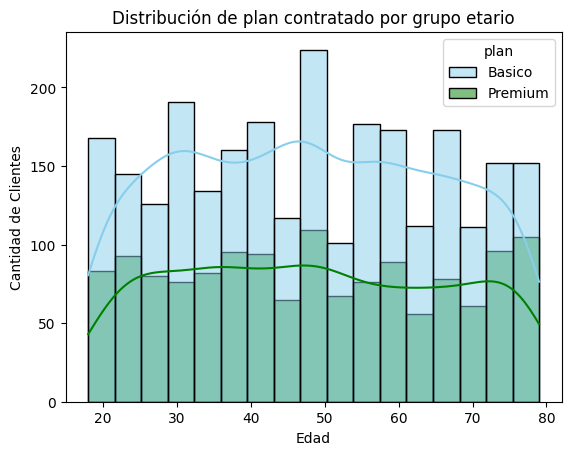

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Edad')
plt.ylabel('Cantidad de Clientes')
plt.title('Distribución de plan contratado por grupo etario')
plt.show()

💡Insights: 
- La distribución de ambos tipos de planes mantienen una forma simétrica, no se observan desviaciones hacia alguno de los extremos.
- Además podemos observar que hay una predominancia de personas con planes contratados en los grupos etarios de entre los 45 y 50 años, pues podemos ver un alza en ambos grupos al estar cerca de llegar a los 50 años de edad.
- La principal diferencia entre los planes es la estabilidad con la que se mantiene el plan premium a lo largo de todos los grupos etarios, mientras que el plan básico presenta disminuciones en ciertos grupos etarios, muy probablemente porque proceden a contratar un plan premium o porque se cambian de compañia, valdría la pena hacer un análisis de esos datos. 

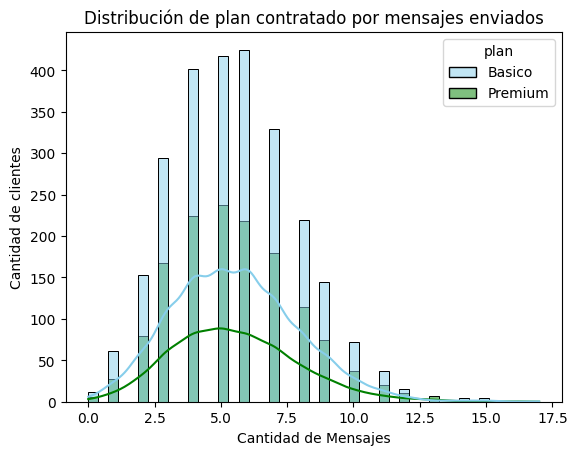

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de plan contratado por mensajes enviados')
plt.show()

💡Insights: 
- Se observa una distribución con sesgo a la derecha (*Right-skewed*), muy probablemente debido a valores que si pueden ser reales pero que no fueron tan frecuentes. Ahora bien, si observamos detenidamente esos datos *outliers* son mayormente en el plan *Premium* lo que nos indica que son oportunidades para ciertas campañas de ofertas para la empresa.

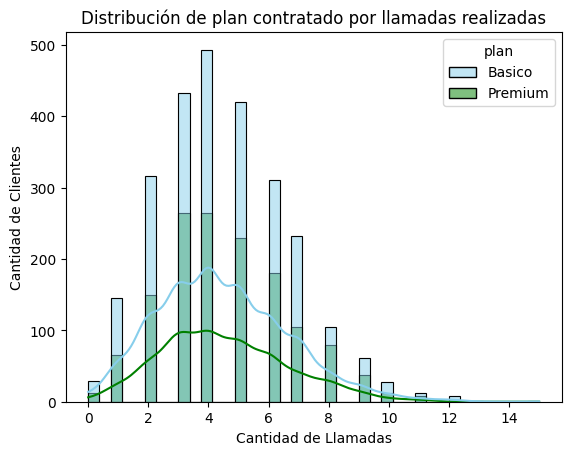

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Clientes')
plt.title('Distribución de plan contratado por llamadas realizadas')
plt.show()

💡Insights: 
- Nuevamente observamos una distribución con sesgo a la derecha, con una franca prevalencia de altas cantidades de llamadas realizadas por los clientes con plan *Premium* en comparación con los de plan *Basico*.
- Podría pensar que hay dos oportunidades en este hallazgo, pues podría averiguarse porque el plan *Basico* genera tan pocas llamadas y planear alguna campaña o modificación al plan para incrementarlas. Además de la oportunidad, al igual que con los mensajes de texto, de generar una campaña para los clientes con plan *Premium*.

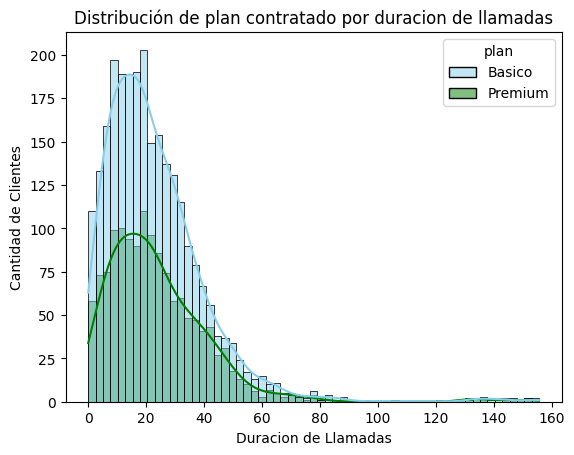

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel('Duracion de Llamadas')
plt.ylabel('Cantidad de Clientes')
plt.title('Distribución de plan contratado por duracion de llamadas')
plt.show()

💡Insights: 
- En este caso se observa una distribución con sesgo extremo a la derecha, se observan datos *outliers*, que podrian ser reales y, por tanto, se deben mantener al ser clientes que pueden generar por altos consumos algun ingreso mayor en alguna medida. Nuevamente estos outliers se concentran en los clientes con el plan *Premium*.
- Se observa una alza en la duración de las llamadas en los clientes con plan *Basico* sobre los de plan *Premium*, pero esto se puede deber a que hay más usuarios con este tipo de plan que con *Premium*. Igualmente este dato nos puede ir guíando hacia en que aspecto debe de trabajarse una oferta o campaña para que hagan mayor cantidad de llamadas y se mantenga esas altas duraciones. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

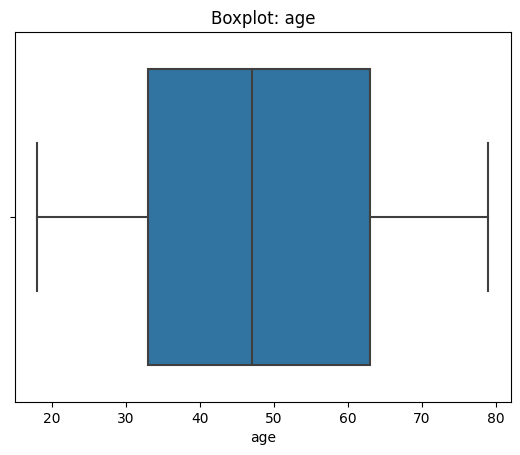

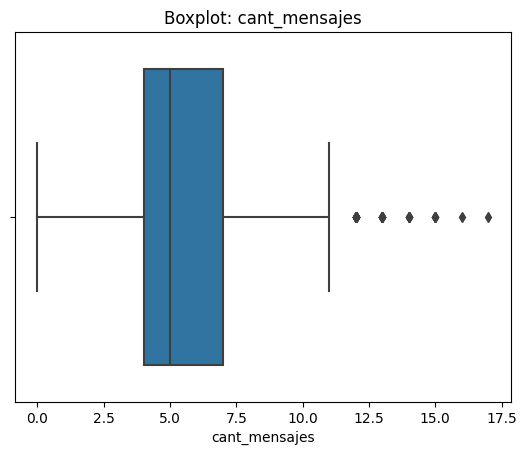

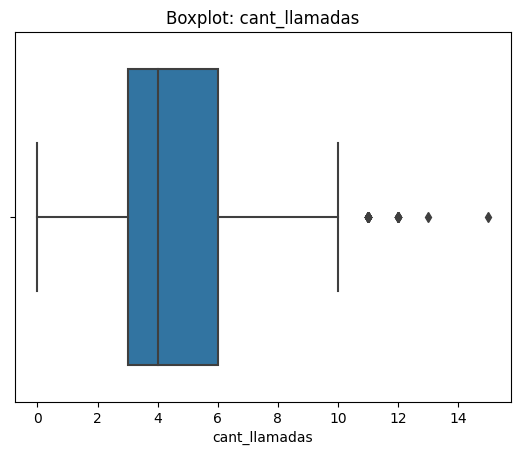

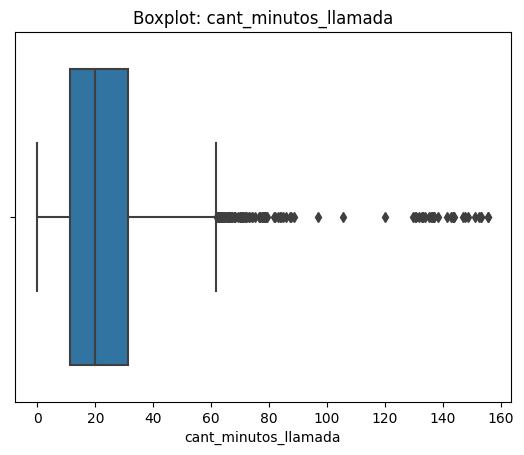

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']]

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers.
- cant_mensajes y cant_llamadas: presentan una cantidad moderada de *outliers* en el extremo derecho de la gráfica generando un sesgo hacia la derecha.
- cant_minutos_llamada: presenta una cantidad basta de datos *outliers* en el extremo derecho de la gráfica causando un sesgo hacia la derecha. 

In [35]:
# Calcular límites con el método IQR
columnas_limites = user_profile[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']]
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    limite_superior=Q3+1.5*IQR
    print("limite_superior de ",col,":",limite_superior)


limite_superior de  cant_mensajes : 11.5
limite_superior de  cant_llamadas : 10.5
limite_superior de  cant_minutos_llamada : 61.8575


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites.describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [37]:
valores_mayores_limite_superior=(user_profile['cant_minutos_llamada']> 61.8575).sum()
print('Valores mayores al limite superior de cant_minutos_llamada:', valores_mayores_limite_superior)

porc_valores_mayores_limite_superior=(user_profile['cant_minutos_llamada']>61.8575).mean()
print('Proporcion de valores mayores al limite superior de cant_minutos_llamada:', porc_valores_mayores_limite_superior)

Valores mayores al limite superior de cant_minutos_llamada: 109
Proporcion de valores mayores al limite superior de cant_minutos_llamada: 0.02725681420355089


💡Insights: 
- En los casos de `cant_mensajes` y `cant_llamadas` yo recomendaría mantener los outliers pues son valores no tan distantes al límite superior que se calcula, además que dentro del contexto son datos que son no tan frecuentes pero si reales y, por tanto, deben de ser tomados en cuenta en los análisis estadísticos. 
- En el caso de `cant_minutos_llamada` mi recomendación es un CAP, talvez, con el valor del percentil 99 con la finalidad de que los datos no se modifiquen tanto, pues hay una diferencia muy significativa entre el limite superior calculado y el valor máximo documentado. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if pd.isna(llamadas) or pd.isna(mensajes):
        return 'Error de datos'
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [39]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']
    
    if pd.isna(edad):
        return 'Error de datos'
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [45]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

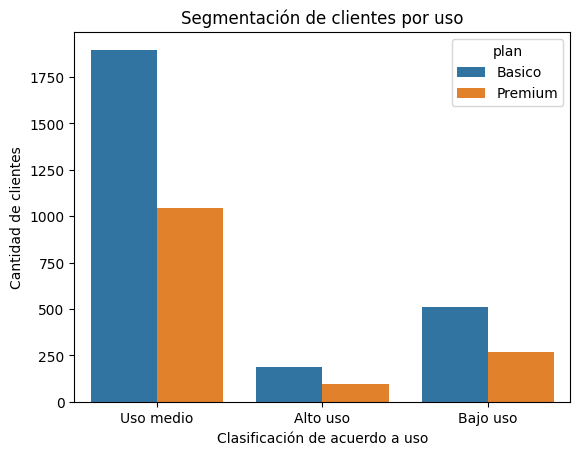

In [50]:
# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile, hue='plan')
plt.xlabel('Clasificación de acuerdo a uso')
plt.ylabel('Cantidad de clientes')
plt.title('Segmentación de clientes por uso')
plt.show()

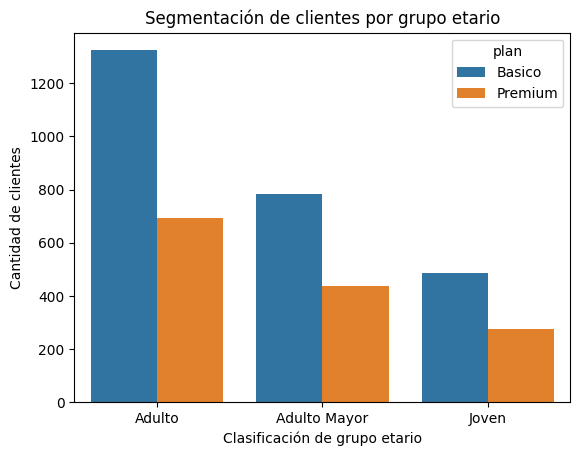

In [52]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile, hue='plan')
plt.xlabel('Clasificación de grupo etario')
plt.ylabel('Cantidad de clientes')
plt.title('Segmentación de clientes por grupo etario')
plt.show()

**Comentario:** 
- Se agrega el `hue=plan` para poder visualizar adicional a la segmentación solicitada y recomendada, también información relevante como es que grupos etarios y que categorias de uso contratan más de cada plan. 


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron datos nulos en múltiples columnas (`city`, `churn_date`, `date`, `duration` y `length`). En el caso de la columna `city` no había una estandarización de dato nulo compatible para los analisis, sino usaban "?", `churn_date` presentaba más del 80% de los datos como nulos, `date` no tenía el formato de fecha ni presentaba estandarización en los datos para un análisis adecuado. Finalmente, `duration` y `length` tenían datos nulos que debían de ser revisados con la finalidad de ver que tanto podrían estar afectando a las medidas estadísticas pues contaban con outliers significativos.
- Igualmente se encontraron valores sentinel como *-999* y fechas imposibles en los registros como datos del *2026*. Se recomendó la omisión de esos datos pues no representaban cambios en el análisis estadístico si se retiraban de los cálculos.


🔍 **Segmentos por Edad**
- Se identifican tres grupos etarios: *Joven*, *Adulto* y *Adulto mayor*, como podemos observar en los gráficos hay una alta prevalencia de clientes *Adultos* y *Adultos mayores* en comparación con *Jovenes*, esto independientemente del plan que se tenga contratado pues persiste la prevalencia de esos grupos etarios en el mercado. 

📊 **Segmentos por Nivel de Uso**
- Se puede observar que hay un predominio franco del segmento de *Uso medio* en el mercado, con un dato llamativo que nos indica que el plan *Basico* en todos los segmentos tiene un mayor uso que el los planes *Premium*.

- Esto sugiere que a mayor la edad de la población mayor es la probabilidad de que este contratando un plan y consumienda de esta compañía, pero habría que hacer un análisis adicional para valorar que factores son los que causan que el consumo en el segmento *Joven* de la población sea menor. También podría concluirse que el consumo es mayor en la población con plan *Basico* lo que sugiere que hay un incremento en la oportunidad de desarrollo de ese segmento del mercado con distintas campañas. 


💡 **Recomendaciones**
Podría centrarse los esfuerzos de campañas para incrementar el consumo de planes en la población del segmento *Adulto* y *Adulto mayor* en el plan *Basico* pues es donde se tiene la mayor oportunidad de ganancia en este momento. Ahora bien, de manera especial habría que valorar porque la población *Joven* no está presentando los mismos indices de consumo de planes de la compañía y valorar hacer campañas o modificaciones en planes especiales para ciertos grupos etarios de la población, con la finalidad de aumentar los consumos y contrataciones. 





---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`